In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# 1. Data Loading & Exploration

In [2]:
# Load dataset using Pandas
df=pd.read_csv("diabetes.csv")

In [3]:
# Show first few rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Check dataset shape
df.shape

(768, 9)

In [5]:
# Check for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
# Show basic statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# Check data type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# 2. Data Preprocessing

In [9]:
# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [10]:
# Perform Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3.Model Training and Model Evaluation

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(max_depth=5, random_state=42)
}

Model: Logistic Regression
Accuracy : 0.7467532467532467
Precision: 0.6379310344827587
Recall   : 0.6727272727272727
F1 Score : 0.6548672566371682
ROC-AUC  : 0.7303030303030302
Model: KNN
Accuracy : 0.6623376623376623
Precision: 0.5245901639344263
Recall   : 0.5818181818181818
F1 Score : 0.5517241379310345
ROC-AUC  : 0.6444444444444444
Model: Decision Tree
Accuracy : 0.7922077922077922
Precision: 0.7446808510638298
Recall   : 0.6363636363636364
F1 Score : 0.6862745098039216
ROC-AUC  : 0.7575757575757576
Model: Random Forest
Accuracy : 0.7662337662337663
Precision: 0.6862745098039216
Recall   : 0.6363636363636364
F1 Score : 0.660377358490566
ROC-AUC  : 0.7373737373737373


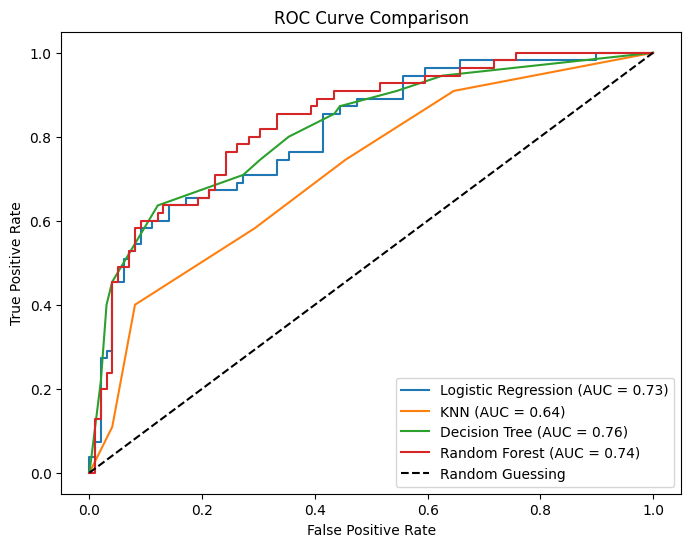

In [12]:
results = []
plt.figure(figsize=(8,6))

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    results.append([name, acc, prec, rec, f1, roc_auc])

    # Plot ROC Curve for each model
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

    # Print Metrics
    print("="*50)
    print("Model:", name)
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)
    print("ROC-AUC  :", roc_auc)

# ROC Curve Visualization
plt.plot([0,1], [0,1], linestyle='--', color='black', label='Random Guessing')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

# 4.Best Model Selection

In [13]:
# Compare All Models
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.746753,0.637931,0.672727,0.654867,0.730303
1,KNN,0.662338,0.524590,0.581818,0.551724,0.644444
2,Decision Tree,0.792208,0.744681,0.636364,0.686275,0.757576
3,Random Forest,0.766234,0.686275,0.636364,0.660377,0.737374


In [17]:
# Best Model Selection
best_model_name = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]
print("Best Model Based on ROC-AUC Score:")
print(best_model_name)

Best Model Based on ROC-AUC Score:
Decision Tree


In [18]:
# Save the Best Model
best_model = models[best_model_name]
joblib.dump(best_model, "diabetes_model.pkl")
print("Model Saved Successfully as diabetes_model.pkl")

Model Saved Successfully as diabetes_model.pkl
